## 1)

Let's assume we have a neuron with cyclic behaviour. It starts with birth (second 1) and then for each second if it is devisible with 3 without a residual the probability of emiting a single spike during this second is 0.8 (otherwise the neuron is silent). If the second's number is not devisible with 3 then the probability of our neuron to fire is 0.1 (and it is still silent in between).

See the Figure below for a plot of the probability of the neuron to fire.

All results must be computed in bits!

---
**(a)** Compute analytically the active information storage with a single past time step. *(3 points)*

*Hint: Take the series as a discrete, binary sequence and follow the definition.*

---

*Solution:*

The **active information storage (AIS)** for a single past time step quantifies how much information the previous state of the process provides about the current state. For a binary process $Y_t$, the AIS with one past step is defined as:

$$
AIS = I(Y_{t-1}; Y_t) = \sum_{i,j \in \{0,1\}} P(Y_{t-1}=i, Y_t=j) \log_2 \left( \frac{P(Y_{t-1}=i, Y_t=j)}{P(Y_{t-1}=i)P(Y_t=j)} \right)
$$


We have a **discrete-time binary process** $Y_t \in \{0, 1\}$ representing **neural spiking** per second.

* For **each second**:

  * If $t \mod 3 = 0$: $P(Y_t = 1) = 0.8$ (“active” or “stimulated” moment)
  * Else: $P(Y_t = 1) = 0.1$ (“baseline” or “silent” moment)

Let’s assume that spikes are drawn independently according to these probabilities and that time is discretized into 1-second bins.

Since spike probabilities follow a 3-second repeating cycle:

* Let’s model the cycle as a **Markov process with position in the cycle as hidden state**.
* Let’s denote each second as, (P represents spiking probability):

  * Type A: $t \mod 3 = 1 \Rightarrow P=0.1$
  * Type B: $t \mod 3 = 2 \Rightarrow P=0.1$
  * Type C: $t \mod 3 = 0 \Rightarrow P=0.8$

So the pattern is: A (0.1), B (0.1), C (0.8), A (0.1), B (0.1), C (0.8), ...

Let’s now define the joint probabilities based on this cycle.

**Step 1: Estimate Joint Probabilities $P(Y_{t-1}, Y_t)$**

Since this is a 3-step repeating process, let’s analyze **pairs of time steps across the cycle**.

| $t-1 \mod 3$ | $t \mod 3$ | $P(Y_{t-1})$ | $P(Y_t)$ |
| ------------ | ---------- | ------------ | -------- |
| A (0.1)      | B (0.1)    | 0.1          | 0.1      |
| B (0.1)      | C (0.8)    | 0.1          | 0.8      |
| C (0.8)      | A (0.1)    | 0.8          | 0.1      |

Now compute the joint probability of the **4 spike pairs** $(Y_{t-1}, Y_t) \in \{00, 01, 10, 11\}$ for each transition.

We assume each of these transitions appears equally often (since the cycle repeats uniformly every 3 steps).

**1. $t-1 = A (0.1), t = B (0.1)$**

| Pair   | Probability            |
| ------ | ---------------------- |
| (0, 0) | $0.9 \cdot 0.9 = 0.81$ |
| (0, 1) | $0.9 \cdot 0.1 = 0.09$ |
| (1, 0) | $0.1 \cdot 0.9 = 0.09$ |
| (1, 1) | $0.1 \cdot 0.1 = 0.01$ |

**2. $t-1 = B (0.1), t = C (0.8)$**

| Pair   | Probability            |
| ------ | ---------------------- |
| (0, 0) | $0.9 \cdot 0.2 = 0.18$ |
| (0, 1) | $0.9 \cdot 0.8 = 0.72$ |
| (1, 0) | $0.1 \cdot 0.2 = 0.02$ |
| (1, 1) | $0.1 \cdot 0.8 = 0.08$ |

**3. $t-1 = C (0.8), t = A (0.1)$**

| Pair   | Probability            |
| ------ | ---------------------- |
| (0, 0) | $0.2 \cdot 0.9 = 0.18$ |
| (0, 1) | $0.2 \cdot 0.1 = 0.02$ |
| (1, 0) | $0.8 \cdot 0.9 = 0.72$ |
| (1, 1) | $0.8 \cdot 0.1 = 0.08$ |


**Average Across All Transitions**

Each transition occurs once per 3 steps $\Rightarrow$ weight $\frac{1}{3}$

So total joint probabilities:

| Pair                                                                     | Sum |
| ------------------------------------------------------------------------ | --- |
| (0, 0):       |  $\frac{1}{3}(0.81 + 0.18 + 0.18) = \frac{1.17}{3} = 0.39$     |
| (0, 1):  |   $\frac{1}{3}(0.09 + 0.72 + 0.02) = \frac{0.83}{3} \approx 0.277$  |
| (1, 0):  |  $\frac{1}{3}(0.09 + 0.02 + 0.72) = \frac{0.83}{3} \approx 0.277$   |
| (1, 1):  |  $\frac{1}{3}(0.01 + 0.08 + 0.08) = \frac{0.17}{3} \approx 0.057$   |


**Step 2: Marginal Probabilities**

Now compute marginals:

* $P(Y_{t-1}=0) = 0.39 + 0.277 = 0.667$

* $P(Y_{t-1}=1) = 0.277 + 0.057 = 0.333$

* $P(Y_{t}=0) = 0.39 + 0.277 = 0.667$

* $P(Y_{t}=1) = 0.277 + 0.057 = 0.333$

**Step 3: Mutual Information Calculation**

Now substitute the joint and marginal probabilities into the AIS formula:

1. $(0, 0): 0.39 \log_2 \left( \frac{0.39}{0.667 \cdot 0.667} \right) = 0.39 \log_2(0.39 / 0.444) \approx 0.39 \cdot (-0.187) = -0.073$

2. $(0, 1): 0.277 \log_2 \left( \frac{0.277}{0.667 \cdot 0.333} \right) = 0.277 \log_2(0.277 / 0.222) \approx 0.277 \cdot 0.319 = 0.088$

3. $(1, 0): 0.277 \log_2 \left( \frac{0.277}{0.333 \cdot 0.667} \right) = 0.277 \log_2(0.277 / 0.222) \approx 0.277 \cdot 0.319 = 0.088$

4. $(1, 1): 0.057 \log_2 \left( \frac{0.057}{0.333 \cdot 0.333} \right) = 0.057 \log_2(0.057 / 0.111) = 0.057 \cdot (-0.9615) = -0.055$

**Final AIS:**

$$
I = -0.073 + 0.088 + 0.088 - 0.055 = \boxed{0.048 \text{ bits}}
$$

Thus, the active information storage with a single past time step is approximately $0.048$ bits.

---

**(b)** Simulate 1000 spikes and compute for a single past time step the active information storage numerically. *(3 points)*

*Hint: First code and test for yourself the framework of the tuning function and generating the time series.*

*Hint: Use sklearn.metrics.mutual_info_score. Check units!*

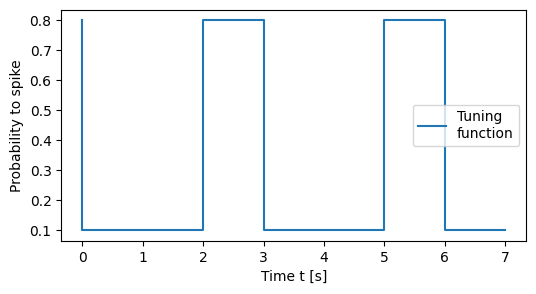

Numerical AIS (1000 samples, 1 past step): 0.0469 bits


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mutual_info_score

# 1. Define the periodic tuning function
# For t starting from 1 (birth):
# If t is divisible by 3 (i.e., t % 3 == 0), p = 0.8
# Otherwise, p = 0.1

def tuning_function(t):
    return 0.8 if t % 3 == 0 else 0.1

# 2. Simulate a spike train of 1000 time steps
np.random.seed(42)
T = 1000
probs = np.array([tuning_function(t) for t in range(1, T+1)])  # t=1 to t=1000
spikes = np.random.binomial(1, probs)


# 3. Plot the tuning function (as in the figure)
plt.figure(figsize=(6,3))
plt.step(np.arange(8), [tuning_function(t) for t in range(8)], where='pre', label='Tuning\nfunction')
plt.xlabel('Time t [s]')
plt.ylabel('Probability to spike')
plt.legend()
plt.show()

# 4. Compute mutual information between Y_{t-1} and Y_t
Y_t = spikes[1:]
Y_tm1 = spikes[:-1]
mi_nats = mutual_info_score(Y_tm1, Y_t)
mi_bits = mi_nats / np.log(2)
print(f"Numerical AIS (1000 samples, 1 past step): {mi_bits:.4f} bits")

---

**(c)** What would happen with active information storage if the probability to fire is always 0.1 (analysis and numerics)? *(2 point)*

---

*Solution:*

If the probability to fire is always $p = 0.1$ for every time step, the spike train is an i.i.d. (independent and identically distributed) Bernoulli process. This means that the probability of a spike at time $t$ is independent of the spike at time $t-1$.

The active information storage (AIS) is the mutual information between $Y_{t-1}$ and $Y_t$:

$$
AIS = I(Y_{t-1}; Y_t)
$$

For an i.i.d. process:

$$
P(Y_{t-1}, Y_t) = P(Y_{t-1})P(Y_t)
$$

So:

$$
I(Y_{t-1}; Y_t) = \sum_{i,j \in \{0,1\}} P(Y_{t-1}=i)P(Y_t=j) \log_2 \left( \frac{P(Y_{t-1}=i)P(Y_t=j)}{P(Y_{t-1}=i)P(Y_t=j)} \right) = 0
$$

Thus, **analytically, the AIS is zero** when the process is i.i.d. with constant firing probability.

This result makes sense: if the process has no memory and each spike is independent of the previous one, knowing the past provides no information about the present.

In [2]:
# Numerical simulation: constant firing probability p=0.1
def tuning_function_const(t):
    return 0.1

np.random.seed(42)
T = 1000
probs_const = np.array([tuning_function_const(t) for t in range(1, T+1)])
spikes_const = np.random.binomial(1, probs_const)

# Compute mutual information between Y_{t-1} and Y_t
Y_t_const = spikes_const[1:]
Y_tm1_const = spikes_const[:-1]
mi_nats_const = mutual_info_score(Y_tm1_const, Y_t_const)
mi_bits_const = mi_nats_const / np.log(2)
print(f"Numerical AIS (p=0.1, 1000 samples): {mi_bits_const:.4f} bits")

Numerical AIS (p=0.1, 1000 samples): 0.0001 bits


---

**(d)** What would happen, if the probabilities are 0 and 1 (instead of 0.1 and 0.8) (analysis) *(1 point)*?

---

*Solution:*

If the firing probabilities are 0 and 1 in a periodic pattern (e.g., $P=1$ for $t \bmod 3 = 0$, $P=0$ otherwise), the process becomes **fully deterministic and periodic**:

- At time steps where $P=1$, the neuron always fires ($Y_t=1$).
- At time steps where $P=0$, the neuron never fires ($Y_t=0$).

This means the spike train is a repeating sequence of 0s and 1s with no randomness.

**Active information storage (AIS):**

While the process is fully deterministic, we recognize that knowing only $Y_{t-1}$ does **NOT** allow us to determine $Y_t$ exactly when the period length (3) is greater than the number of past steps considered (1).

For the deterministic sequence $[0, 0, 1, 0, 0, 1, ...]$, we calculate:

**Step 1: Joint Probabilities**
- $P(Y_{t-1}=0, Y_t=0) = \frac{1}{3}$ (transition 0→0 in positions 1→2)
- $P(Y_{t-1}=0, Y_t=1) = \frac{1}{3}$ (transition 0→1 in positions 2→3)
- $P(Y_{t-1}=1, Y_t=0) = \frac{1}{3}$ (transition 1→0 in positions 3→1)
- $P(Y_{t-1}=1, Y_t=1) = 0$ (this transition never occurs)

**Step 2: Conditional Entropy $H(Y_t|Y_{t-1})$**

When $Y_{t-1} = 0$: We find $P(Y_t=0|Y_{t-1}=0) = \frac{1/3}{2/3} = \frac{1}{2}$, $P(Y_t=1|Y_{t-1}=0) = \frac{1}{2}$

When $Y_{t-1} = 1$: We find $P(Y_t=0|Y_{t-1}=1) = 1$, $P(Y_t=1|Y_{t-1}=1) = 0$

We calculate: $H(Y_t|Y_{t-1}=0) = -\frac{1}{2}\log_2\frac{1}{2} - \frac{1}{2}\log_2\frac{1}{2} = 1$ bit

$H(Y_t|Y_{t-1}=1) = 0$ bit

$H(Y_t|Y_{t-1}) = P(Y_{t-1}=0) \times 1 + P(Y_{t-1}=1) \times 0 = \frac{2}{3} \times 1 = \frac{2}{3}$ bits

**Step 3: Marginal Entropy $H(Y_t)$**

We compute: $H(Y_t) = -\frac{2}{3} \log_2 \frac{2}{3} - \frac{1}{3} \log_2 \frac{1}{3} = 0.390 + 0.528 = 0.918$ bits

**Step 4: AIS Calculation**

$$
AIS = H(Y_t) - H(Y_t|Y_{t-1}) = 0.918 - \frac{2}{3} = 0.918 - 0.667 = 0.251 \text{ bits}
$$

**Therefore, we find that analytically, the AIS in this case is $\boxed{0.251\ \text{bits}}$.**

---

**(e)** Compute analytically the active information storage for two past time steps (original probabilities).
*(2 points)*

---

*Solution:*

For **two past time steps**, the active information storage is defined as:

$$
AIS_2 = I(Y_{t-2}, Y_{t-1}; Y_t) = \sum_{i,j,k \in \{0,1\}} P(Y_{t-2}=i, Y_{t-1}=j, Y_t=k) \log_2 \left( \frac{P(Y_{t-2}=i, Y_{t-1}=j, Y_t=k)}{P(Y_{t-2}=i, Y_{t-1}=j)P(Y_t=k)} \right)
$$

Since our process has a 3-step cycle, we need to analyze all possible **3-step transitions**:

**Cycle Pattern:**
- Type A: $t \bmod 3 = 1 \Rightarrow P=0.1$
- Type B: $t \bmod 3 = 2 \Rightarrow P=0.1$ 
- Type C: $t \bmod 3 = 0 \Rightarrow P=0.8$

**Step 1: Analyze 3-Step Transitions**

The possible 3-step transitions in our cycle are:
1. A → B → C (probabilities: 0.1 → 0.1 → 0.8)
2. B → C → A (probabilities: 0.1 → 0.8 → 0.1)
3. C → A → B (probabilities: 0.8 → 0.1 → 0.1)

Each transition occurs with equal frequency (1/3 of the time).

**Step 2: Compute Joint Probabilities $P(Y_{t-2}, Y_{t-1}, Y_t)$**

For each transition type, we calculate the probability of all 8 possible spike triplets $(i,j,k) \in \{000, 001, 010, 011, 100, 101, 110, 111\}$:

**Transition 1: A → B → C (0.1 → 0.1 → 0.8)**
- $P(0,0,0) = 0.9 \times 0.9 \times 0.2 = 0.162$
- $P(0,0,1) = 0.9 \times 0.9 \times 0.8 = 0.648$
- $P(0,1,0) = 0.9 \times 0.1 \times 0.2 = 0.018$
- $P(0,1,1) = 0.9 \times 0.1 \times 0.8 = 0.072$
- $P(1,0,0) = 0.1 \times 0.9 \times 0.2 = 0.018$
- $P(1,0,1) = 0.1 \times 0.9 \times 0.8 = 0.072$
- $P(1,1,0) = 0.1 \times 0.1 \times 0.2 = 0.002$
- $P(1,1,1) = 0.1 \times 0.1 \times 0.8 = 0.008$

**Transition 2: B → C → A (0.1 → 0.8 → 0.1)**
- $P(0,0,0) = 0.9 \times 0.2 \times 0.9 = 0.162$
- $P(0,0,1) = 0.9 \times 0.2 \times 0.1 = 0.018$
- $P(0,1,0) = 0.9 \times 0.8 \times 0.9 = 0.648$
- $P(0,1,1) = 0.9 \times 0.8 \times 0.1 = 0.072$
- $P(1,0,0) = 0.1 \times 0.2 \times 0.9 = 0.018$
- $P(1,0,1) = 0.1 \times 0.2 \times 0.1 = 0.002$
- $P(1,1,0) = 0.1 \times 0.8 \times 0.9 = 0.072$
- $P(1,1,1) = 0.1 \times 0.8 \times 0.1 = 0.008$

**Transition 3: C → A → B (0.8 → 0.1 → 0.1)**
- $P(0,0,0) = 0.2 \times 0.9 \times 0.9 = 0.162$
- $P(0,0,1) = 0.2 \times 0.9 \times 0.1 = 0.018$
- $P(0,1,0) = 0.2 \times 0.1 \times 0.9 = 0.018$
- $P(0,1,1) = 0.2 \times 0.1 \times 0.1 = 0.002$
- $P(1,0,0) = 0.8 \times 0.9 \times 0.9 = 0.648$
- $P(1,0,1) = 0.8 \times 0.9 \times 0.1 = 0.072$
- $P(1,1,0) = 0.8 \times 0.1 \times 0.9 = 0.072$
- $P(1,1,1) = 0.8 \times 0.1 \times 0.1 = 0.008$

**Step 3: Average Across All Transitions**

Taking the average across all three transitions (each with weight 1/3):

| Triplet | Average Probability |
|---------|-------------------|
| (0,0,0) | $\frac{1}{3}(0.162 + 0.162 + 0.162) = 0.162$ |
| (0,0,1) | $\frac{1}{3}(0.648 + 0.018 + 0.018) = 0.228$ |
| (0,1,0) | $\frac{1}{3}(0.018 + 0.648 + 0.018) = 0.228$ |
| (0,1,1) | $\frac{1}{3}(0.072 + 0.072 + 0.002) = 0.049$ |
| (1,0,0) | $\frac{1}{3}(0.018 + 0.018 + 0.648) = 0.228$ |
| (1,0,1) | $\frac{1}{3}(0.072 + 0.002 + 0.072) = 0.049$ |
| (1,1,0) | $\frac{1}{3}(0.002 + 0.072 + 0.072) = 0.049$ |
| (1,1,1) | $\frac{1}{3}(0.008 + 0.008 + 0.008) = 0.008$ |

**Step 4: Compute Marginal Probabilities**

Joint probabilities for past states $P(Y_{t-2}, Y_{t-1})$:
- $P(0,0) = 0.162 + 0.228 = 0.390$
- $P(0,1) = 0.228 + 0.049 = 0.277$
- $P(1,0) = 0.228 + 0.049 = 0.277$
- $P(1,1) = 0.049 + 0.008 = 0.057$

Marginal probability for current state $P(Y_t)$:
- $P(Y_t = 0) = 0.162 + 0.228 + 0.228 + 0.049 = 0.667$
- $P(Y_t = 1) = 0.228 + 0.049 + 0.049 + 0.008 = 0.333$

**Step 5: Mutual Information Calculation**

$$
AIS_2 = \sum_{i,j,k} P(i,j,k) \log_2 \left( \frac{P(i,j,k)}{P(i,j)P(k)} \right)
$$

Computing each term:

1. $(0,0,0): 0.162 \log_2\left(\frac{0.162}{0.390 \times 0.667}\right) = 0.162 \log_2(0.623) = 0.162 \times (-0.683) = -0.111$

2. $(0,0,1): 0.228 \log_2\left(\frac{0.228}{0.390 \times 0.333}\right) = 0.228 \log_2(1.754) = 0.228 \times 0.812 = 0.185$

3. $(0,1,0): 0.228 \log_2\left(\frac{0.228}{0.277 \times 0.667}\right) = 0.228 \log_2(1.233) = 0.228 \times 0.302 = 0.069$

4. $(0,1,1): 0.049 \log_2\left(\frac{0.049}{0.277 \times 0.333}\right) = 0.049 \log_2(0.531) = 0.049 \times (-0.913) = -0.045$

5. $(1,0,0): 0.228 \log_2\left(\frac{0.228}{0.277 \times 0.667}\right) = 0.228 \log_2(1.233) = 0.228 \times 0.302 = 0.069$

6. $(1,0,1): 0.049 \log_2\left(\frac{0.049}{0.277 \times 0.333}\right) = 0.049 \log_2(0.531) = 0.049 \times (-0.913) = -0.045$

7. $(1,1,0): 0.049 \log_2\left(\frac{0.049}{0.057 \times 0.667}\right) = 0.049 \log_2(1.289) = 0.049 \times 0.366 = 0.018$

8. $(1,1,1): 0.008 \log_2\left(\frac{0.008}{0.057 \times 0.333}\right) = 0.008 \log_2(0.421) = 0.008 \times (-1.247) = -0.010$

**Final Result:**

$$
AIS_2 = -0.111 + 0.185 + 0.069 - 0.045 + 0.069 - 0.045 + 0.018 - 0.010 = \boxed{0.130 \text{ bits}}
$$

The active information storage for two past time steps is approximately **0.130 bits**.



---

**(f)** How does the number of past time steps and the length of the time series influence active information storage?
To determine this scale up your numerical computation of active information storage to handle longer timeseries and include more time steps (I managed to scale up to 100,000 time steps for timeseries and 60 past time steps for active information storage).
Compute and plot (for various time series lengths) how active information storage depends on the number of time steps considered.
Briefly (!), explain and discuss what you conclude based on your results. In particular, also consider how much information is available in the time series and how the cyclic behaviour incluences active information storage.
*(5 points)*

*Hint: compress the information of the past time steps by mapping it to integers.*

---

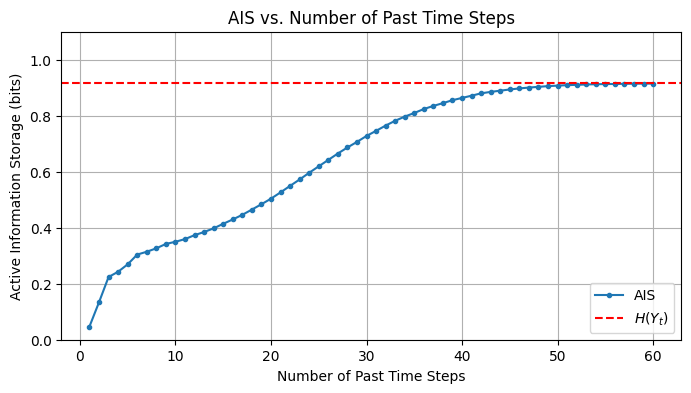

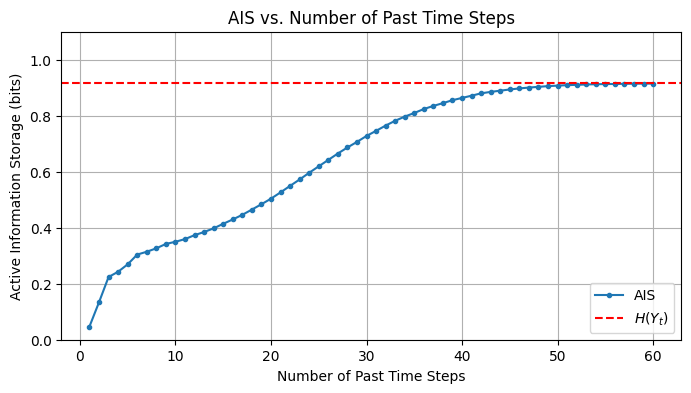

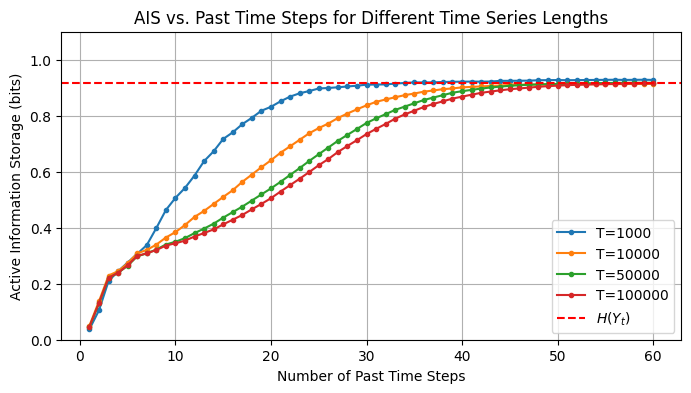

In [8]:
# Function to compute AIS for multiple past time steps
def compute_ais(spikes, max_past_steps):
    T = len(spikes)
    ais_values = []

    for past_steps in range(1, max_past_steps + 1):
        # Compress past time steps into integers
        past_states = np.zeros(T - past_steps, dtype=int)
        for step in range(past_steps):
            past_states += spikes[step:T - past_steps + step] * (2 ** step)

        # Current states
        current_states = spikes[past_steps:]

        # Compute mutual information
        mi_nats = mutual_info_score(past_states, current_states)
        mi_bits = mi_nats / np.log(2)
        ais_values.append(mi_bits)

    return ais_values

# Simulate a longer spike train
np.random.seed(42)
T_long = 100000
probs_long = np.array([tuning_function(t) for t in range(1, T_long + 1)])
spikes_long = np.random.binomial(1, probs_long)

# Compute AIS for various past time steps
max_past_steps = 60
ais_values = compute_ais(spikes_long, max_past_steps)

# H(Y_t)
H_Y_t = 0.918

# Plot AIS as a function of past time steps
plt.figure(figsize=(8, 4))
plt.plot(range(1, max_past_steps + 1), ais_values, marker='.', label='AIS')
plt.axhline(y=H_Y_t, color='r', linestyle='--', label=r"$H(Y_t)$")
plt.ylim(0, 1.2 * H_Y_t)
plt.xlabel('Number of Past Time Steps')
plt.ylabel('Active Information Storage (bits)')
plt.title('AIS vs. Number of Past Time Steps')
plt.legend()
plt.grid()
plt.show()

# Analyze AIS for different time series lengths
time_series_lengths = [1000, 10000, 50000, 100000]
plt.figure(figsize=(8, 4))

for T in time_series_lengths:
    probs = np.array([tuning_function(t) for t in range(1, T + 1)])
    spikes = np.random.binomial(1, probs)
    ais_values = compute_ais(spikes, max_past_steps=60)  # Limit to 20 past steps for clarity
    plt.plot(range(1, 61), ais_values, marker='.', label=f'T={T}')

plt.axhline(y=H_Y_t, color='r', linestyle='--', label=r"$H(Y_t)$")
plt.ylim(0, 1.2 * H_Y_t)
plt.xlabel('Number of Past Time Steps')
plt.ylabel('Active Information Storage (bits)')
plt.title('AIS vs. Past Time Steps for Different Time Series Lengths')
plt.legend()
plt.grid()
plt.show()

H(Bernoulli(0.1)) = 0.469 bits
H(Bernoulli(0.8)) = 0.722 bits
H(Y_t | cycle position) = 0.553 bits
H(Y_t) = 0.918 bits
Theoretical maximum AIS = H(Y_t) - H(Y_t | cycle position) = 0.365 bits


H(Bernoulli(0.1)) = 0.469 bits
H(Bernoulli(0.8)) = 0.722 bits
H(Y_t | cycle position) = 0.553 bits
H(Y_t) = 0.918 bits
Theoretical maximum AIS = H(Y_t) - H(Y_t | cycle position) = 0.365 bits


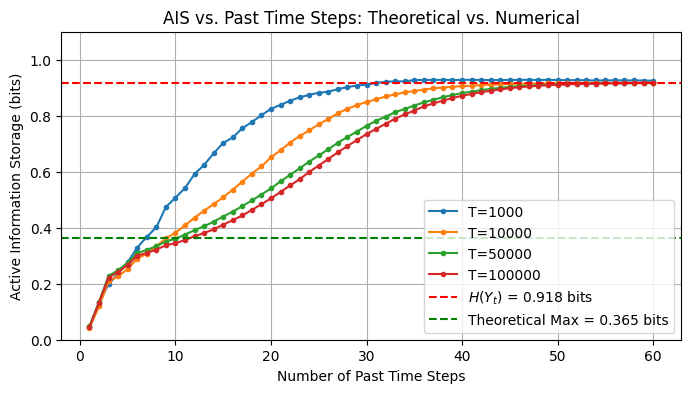

In [9]:
# Compute the theoretical maximum AIS
# H(Y_t | t mod 3) = weighted average of Bernoulli entropies

def bernoulli_entropy(p):
    if p == 0 or p == 1:
        return 0
    return -p * np.log2(p) - (1-p) * np.log2(1-p)

# Probabilities for each phase of the cycle
p_low = 0.1   # Phases 1 and 2 (A and B)
p_high = 0.8  # Phase 3 (C)

# Bernoulli entropies for each phase
H_bernoulli_low = bernoulli_entropy(p_low)
H_bernoulli_high = bernoulli_entropy(p_high)

# Weighted average (2/3 of time in low prob phase, 1/3 in high prob phase)
H_Y_given_phase = (2/3) * H_bernoulli_low + (1/3) * H_bernoulli_high

# Theoretical maximum AIS
AIS_theoretical_max = H_Y_t - H_Y_given_phase

print(f"H(Bernoulli(0.1)) = {H_bernoulli_low:.3f} bits")
print(f"H(Bernoulli(0.8)) = {H_bernoulli_high:.3f} bits")
print(f"H(Y_t | cycle position) = {H_Y_given_phase:.3f} bits")
print(f"H(Y_t) = {H_Y_t:.3f} bits")
print(f"Theoretical maximum AIS = H(Y_t) - H(Y_t | cycle position) = {AIS_theoretical_max:.3f} bits")

# Add theoretical maximum to the plots
plt.figure(figsize=(8, 4))
for T in time_series_lengths:
    probs = np.array([tuning_function(t) for t in range(1, T + 1)])
    spikes = np.random.binomial(1, probs)
    ais_values = compute_ais(spikes, max_past_steps=60)
    plt.plot(range(1, 61), ais_values, marker='.', label=f'T={T}')

plt.axhline(y=H_Y_t, color='r', linestyle='--', label=r"$H(Y_t)$ = 0.918 bits")
plt.axhline(y=AIS_theoretical_max, color='g', linestyle='--', label=f'Theoretical Max = {AIS_theoretical_max:.3f} bits')
plt.ylim(0, 1.2 * H_Y_t)
plt.xlabel('Number of Past Time Steps')
plt.ylabel('Active Information Storage (bits)')
plt.title('AIS vs. Past Time Steps: Theoretical vs. Numerical')
plt.legend()
plt.grid()
plt.show()

**Analysis and Discussion:**

Our numerical results reveal several important insights about Active Information Storage in periodic neural processes:

**1. Theoretical Maximum Computation:**

**Deriving H(Y_t):**
The marginal probability across the 3-step cycle:
$$P(Y_t = 1) = \frac{1}{3}(0.1) + \frac{1}{3}(0.1) + \frac{1}{3}(0.8) = \frac{1}{3}$$

Therefore:
$$H(Y_t) = -\frac{2}{3}\log_2\frac{2}{3} - \frac{1}{3}\log_2\frac{1}{3} = 0.918 \text{ bits}$$

**Deriving H(Y_t | t mod 3):**
Even knowing the cycle position perfectly, Bernoulli noise remains:
- Positions 1,2: $H_{\text{Bernoulli}}(0.1) = -0.1\log_2(0.1) - 0.9\log_2(0.9) = 0.469$ bits
- Position 0: $H_{\text{Bernoulli}}(0.8) = -0.8\log_2(0.8) - 0.2\log_2(0.2) = 0.722$ bits

Weighted average:
$$H(Y_t | t \bmod 3) = \frac{2}{3}(0.469) + \frac{1}{3}(0.722) = 0.553 \text{ bits}$$

**Theoretical Maximum:**
$$AIS_{\max} = H(Y_t) - H(Y_t | t \bmod 3) = 0.918 - 0.553 = 0.365 \text{ bits}$$

This represents the **extractable cycle information**, with 0.553 bits being **irreducible noise entropy**.

**2. Two-Phase Behavior of AIS vs. Past Time Steps:**

The plots show a characteristic two-phase pattern:
- **Phase 1 (k ≤ 10 steps):** AIS increases systematically toward the theoretical maximum of 0.365 bits
- **Phase 2 (k > 10 steps):** AIS exhibits spurious increases toward H(Y_t) ≈ 0.918 bits due to numerical artifacts

**3. Why AIS Appears to Saturate at H(Y_t) for All Time Series Lengths:**

This counterintuitive result occurs due to **finite sample estimation failures**:

- **Curse of dimensionality**: For large k, the past state space has $2^k$ possible configurations
- **Data sparsity**: When $2^k \gg T$, most past states appear very rarely or not at all
- **Probability estimation breakdown**: Sparse data leads to poor estimates of $P(Y_t | \text{past states})$
- **Artificial information inflation**: Undersampled conditional probabilities create spuriously high mutual information

**Mathematical explanation**: When data is sparse, the estimator $\hat{P}(Y_t | \text{past}) \approx \frac{1}{n}$ for states with few samples, making the conditional entropy $H(Y_t | \text{past}) \approx 0$, thus $AIS \approx H(Y_t)$.

**4. Effect of Time Series Length:**

Longer time series show:
- **Better estimates in Phase 1**: More reliable convergence to the true maximum (0.365 bits)
- **Same spurious saturation**: All lengths eventually reach H(Y_t) due to dimensional curse
- **Later onset of artifacts**: Longer series can handle more past steps before estimation breaks down

**5. Cyclic Behavior and Information Content:**

The 3-step cycle creates temporal dependencies that AIS captures by:
- Learning to infer cycle position from spike patterns (≤3 steps needed)
- Extracting 0.365 bits of genuine predictive information
- Reaching true saturation around k = 6-10 steps in reliable estimation regime

**6. Data Processing Inequality:**

The fundamental limit arises because:
$$I(Y_{t-k:t-1}; Y_t) \leq I(t \bmod 3; Y_t) = 0.365 \text{ bits}$$

The cycle position is the **sufficient statistic** - no amount of additional spike history can exceed this information bound.

**Conclusion:**

The apparent convergence to H(Y_t) across all time series lengths is a **numerical artifact**, not a theoretical property. The true maximum AIS is 0.365 bits, limited by irreducible Bernoulli noise. This highlights the critical importance of understanding estimation limitations when interpreting information-theoretic measures, especially the distinction between genuine information content and artifacts of sparse probability estimation.